In [17]:
import pandas as pd

df = pd.read_excel("Data_Intra.xlsx",sheet_name = "Sheet1",skiprows = 2)

arr = []
for i in df.columns:
    if "Unnamed" not in i:
        arr.append(i)
        

col_ = []

for i in range(len(arr)):
    col_.append('Dates' +  arr[i])
    col_.append(arr[i])
    col_.append('Blank ' + arr[i])

df = pd.read_excel("Data_Intra.xlsx",sheet_name = "Sheet1",skiprows = 3)

df.columns = col_[:-1]

dict_curr = {}
for i in range(len(arr)):
    temp = df[['Dates'+ arr[i], arr[i]]]
    
    temp = temp.rename({'Dates'+ arr[i]: 'Date', arr[i]:'close'},axis = 1)
    temp = temp.set_index("Date").dropna()
    
    dict_curr[arr[i]]= temp

In [18]:
df = pd.read_excel("Data_Intra.xlsx",sheet_name = "Sheet1",skiprows = 3)

df.columns = col_[:-1]

dict_curr = {}
for i in range(len(arr)):
    temp = df[['Dates'+ arr[i], arr[i]]]
    
    temp = temp.rename({'Dates'+ arr[i]: 'Date', arr[i]:'close'},axis = 1)
    temp = temp.set_index("Date").dropna()
    
    dict_curr[arr[i]]= temp

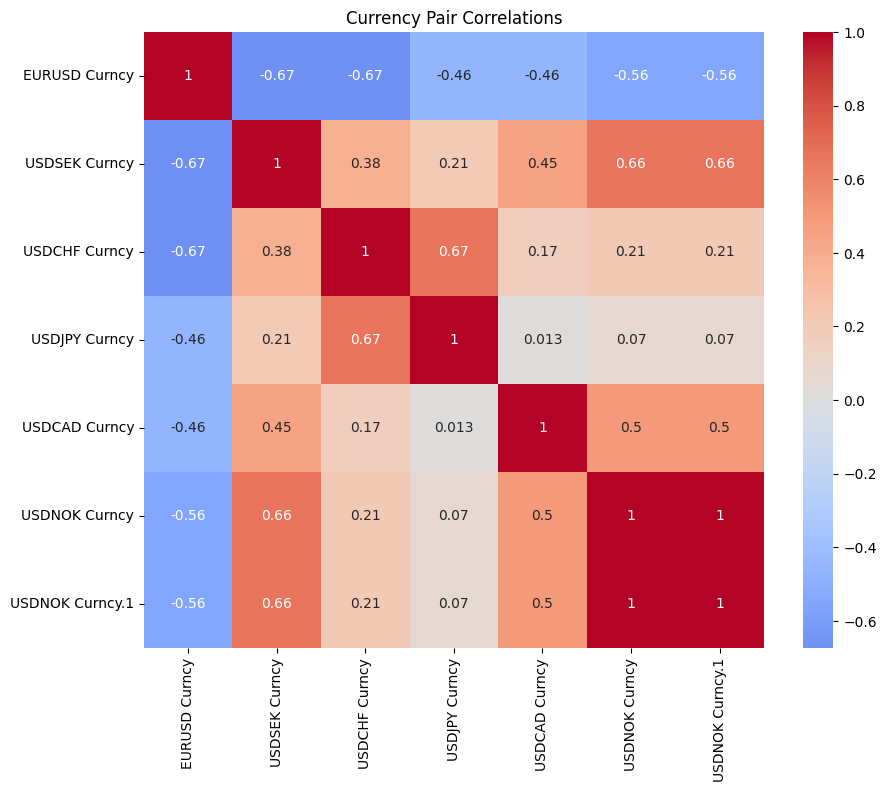


PCA Components:
     EURUSD Curncy  USDSEK Curncy  USDCHF Curncy  USDJPY Curncy  \
PC1       0.308992      -0.514076      -0.195346      -0.109325   
PC2      -0.313356       0.106572       0.603070       0.580670   

     USDCAD Curncy  USDNOK Curncy  USDNOK Curncy.1  
PC1      -0.154180      -0.532150        -0.532150  
PC2      -0.045537      -0.306191        -0.306191  

Explained Variance:
[0.61959255 0.20167065]


,USDSEK Curncy/USDCHF Curncy_rel,USDSEK Curncy/USDJPY Curncy_rel,USDSEK Curncy/USDCAD Curncy_rel,USDSEK Curncy/USDNOK Curncy_rel,USDSEK Curncy/USDNOK Curncy.1_rel,USDCHF Curncy/USDJPY Curncy_rel,USDCHF Curncy/USDCAD Curncy_rel,USDCHF Curncy/USDNOK Curncy_rel,USDCHF Curncy/USDNOK Curncy.1_rel,USDJPY Curncy/USDCAD Curncy_rel,USDJPY Curncy/USDNOK Curncy_rel,USDJPY Curncy/USDNOK Curncy.1_rel,USDCAD Curncy/USDNOK Curncy_rel,USDCAD Curncy/USDNOK Curncy.1_rel,USDNOK Curncy/USDNOK Curncy.1_rel
Date,,,,,,,,,,,,,,,
2025-04-01 19:00:00,0.931258,1.661339,0.288290,-0.594789,-0.594789,0.730081,-0.642968,-1.526047,-1.526047,-1.373049,-2.256129,-2.256129,-0.883079,-0.883079,0.0
2025-04-01 19:10:00,-0.126735,1.854290,0.196584,0.166898,0.166898,1.981024,0.323318,0.293633,0.293633,-1.657706,-1.687392,-1.687392,-0.029686,-0.029686,0.0
2025-04-01 19:20:00,-0.015813,0.008143,-2.006462,0.334141,0.334141,0.023956,-1.990648,0.349954,0.349954,-2.014604,0.325998,0.325998,2.340602,2.340602,0.0
2025-04-01 19:30:00,-1.189278,1.239168,-1.734963,-0.219815,-0.219815,2.428446,-0.545685,0.969463,0.969463,-2.974131,-1.458983,-1.458983,1.515148,1.515148,0.0
2025-04-01 19:40:00,3.046665,2.527942,0.573295,0.660691,0.660691,-0.518723,-2.473370,-2.385974,-2.385974,-1.954647,-1.867250,-1.867250,0.087396,0.087396,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-12 04:10:00,0.191082,0.271187,0.161899,0.310135,0.310135,0.080104,-0.029184,0.119053,0.119053,-0.109288,0.038948,0.038948,0.148237,0.148237,0.0
2025-04-12 04:20:00,-0.109269,-0.052108,-0.187784,-0.782344,-0.782344,0.057161,-0.078515,-0.673075,-0.673075,-0.135676,-0.730236,-0.730236,-0.594560,-0.594560,0.0
2025-04-12 04:30:00,0.190005,0.156936,0.044040,0.127885,0.127885,-0.033069,-0.145965,-0.062121,-0.062121,-0.112896,-0.029051,-0.029051,0.083845,0.083845,0.0


,EURUSD Curncy,USDSEK Curncy,USDCHF Curncy,USDJPY Curncy,USDCAD Curncy,USDNOK Curncy,USDNOK Curncy.1
Date,,,,,,,
2025-04-01 19:00:00,0,-1,1,1,0,0,0
2025-04-01 19:10:00,0,-1,-1,1,0,0,0
2025-04-01 19:20:00,0,1,1,1,-1,0,0
2025-04-01 19:30:00,0,1,-1,1,-1,0,0
2025-04-01 19:40:00,0,-1,1,1,0,0,0
...,...,...,...,...,...,...,...
2025-04-12 04:10:00,0,0,0,0,0,0,0
2025-04-12 04:20:00,0,0,0,0,0,0,0
2025-04-12 04:30:00,0,0,0,0,0,0,0


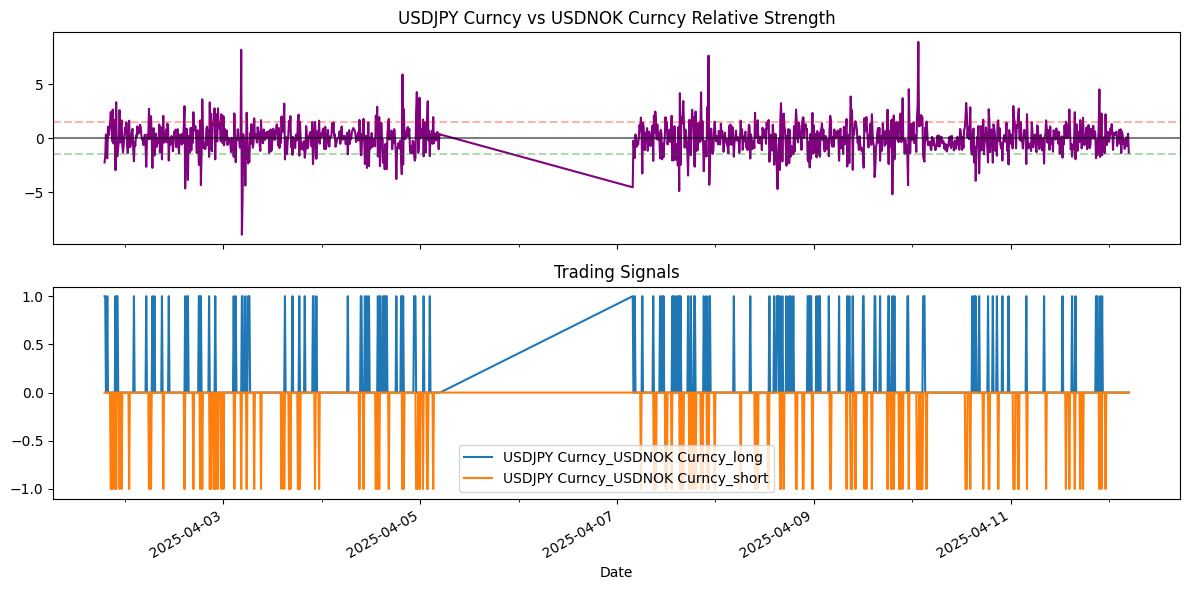


Strategy Performance:
Sharpe Ratio: -3.93
Max Drawdown: -33.52%


In [21]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

class CrossCurrencyStrategy:
    def __init__(self, data_dict, lookback=60, z_threshold=1.5):
        """
        Initialize with dictionary of currency pair DataFrames
        { 'EURUSD': df, 'GBPUSD': df, ... } where each df has 'close' column
        """
        self.data_dict = data_dict
        self.pairs = list(data_dict.keys())
        self.lookback = lookback
        self.z_threshold = z_threshold
        self._prepare_data()

    def _prepare_data(self):
        """Combine all currency data into a single DataFrame"""
        self.combined = pd.DataFrame()
        for pair, df in self.data_dict.items():
            self.combined[pair] = df['close']
        self.combined = self.combined.dropna()
        
        # Calculate returns
        self.returns = self.combined.pct_change().dropna()
        
    def calculate_correlation_matrix(self, rolling_window=30):
        """Calculate rolling correlation matrix"""
        corr_matrix = self.returns.rolling(rolling_window).corr().dropna()
        self.rolling_corr = corr_matrix.groupby(level=0).apply(lambda x: x)
        return self.rolling_corr
    
    def plot_correlation_heatmap(self):
        """Visualize the average correlation matrix"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.returns.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Currency Pair Correlations')
        plt.show()
        
    def pca_analysis(self, n_components=2):
        """Perform PCA on returns to identify dominant market drivers"""
        pca = PCA(n_components=n_components)
        pca.fit(self.returns)
        
        self.pca_components = pd.DataFrame(
            pca.components_,
            columns=self.returns.columns,
            index=[f'PC{i+1}' for i in range(n_components)]
        )
        
        self.pca_explained = pca.explained_variance_ratio_
        return self.pca_components, self.pca_explained
    
    def relative_strength_zscore(self):
        """Calculate z-scores of relative performance between pairs"""
        # Normalized returns over lookback period
#         norm_rets = self.returns.rolling(self.lookback).apply(zscore).dropna()
        def rolling_zscore(x):
            return (x[-1] - x.mean()) / x.std()


        norm_rets = self.returns.rolling(self.lookback).apply(rolling_zscore, raw=True).dropna()

        # Pairwise relative strength
        self.rel_strength = pd.DataFrame(index=norm_rets.index)
        
        # Compare each pair against others in the same currency bloc
        for i, pair1 in enumerate(self.pairs):
            for pair2 in self.pairs[i+1:]:
                if pair1[:3] == pair2[:3]:  # Same base currency (EURUSD vs EURGBP)
                    col_name = f"{pair1}/{pair2}_rel"
                    self.rel_strength[col_name] = norm_rets[pair1] - norm_rets[pair2]
                elif pair1[3:] == pair2[3:]:  # Same quote currency (EURUSD vs GBPUSD)
                    col_name = f"{pair1}/{pair2}_rel"
                    self.rel_strength[col_name] = norm_rets[pair1] - norm_rets[pair2]
        
        return self.rel_strength
    
    def generate_signals(self):
        """Generate trading signals based on relative strength divergence"""
        rel_strength = self.relative_strength_zscore()
        self.signals = pd.DataFrame(index=rel_strength.index)
        
        for col in rel_strength.columns:
            pair1, pair2 = col.split('_')[0].split('/')
            
            # Long pair1/short pair2 when pair1 is relatively weak
            self.signals[f"{pair1}_{pair2}_long"] = (
                (rel_strength[col] < -self.z_threshold).astype(int)
            )
            
            # Short pair1/long pair2 when pair1 is relatively strong
            self.signals[f"{pair1}_{pair2}_short"] = (
                (rel_strength[col] > self.z_threshold).astype(int) * -1
            )
        
        # Aggregate signals per currency pair
        final_signals = pd.DataFrame(index=self.signals.index)
        for pair in self.pairs:
            long_cols = [col for col in self.signals.columns if col.startswith(f"{pair}_") and col.endswith("_long")]
            short_cols = [col for col in self.signals.columns if col.startswith(f"{pair}_") and col.endswith("_short")]
            
            final_signals[pair] = self.signals[long_cols].sum(axis=1) + self.signals[short_cols].sum(axis=1)
            final_signals[pair] = np.where(final_signals[pair] > 0, 1, 
                                         np.where(final_signals[pair] < 0, -1, 0))
        
        return final_signals
    
    def backtest_strategy(self, trade_size=10000, spread_cost=0.0002):
        """Backtest the cross-currency strategy"""
        signals = self.generate_signals()
        portfolio = pd.DataFrame(index=signals.index)
        
        # Calculate returns
        portfolio['strategy_returns'] = (signals.shift(1) * self.returns).sum(axis=1)
        
        # Account for spread costs (approximate)
        trades = signals.diff().abs().sum(axis=1)
        portfolio['costs'] = trades * spread_cost
        
        # Calculate equity curve
        portfolio['net_returns'] = portfolio['strategy_returns'] - portfolio['costs']
        portfolio['cum_returns'] = (1 + portfolio['net_returns']).cumprod()
        
        # Performance metrics
        sharpe = np.sqrt(252) * portfolio['net_returns'].mean() / portfolio['net_returns'].std()
        max_dd = (portfolio['cum_returns'] / portfolio['cum_returns'].cummax() - 1).min()
        
        return portfolio, {'sharpe': sharpe, 'max_drawdown': max_dd}
    
    def plot_signals(self, pair1, pair2):
        """Visualize signals for a specific pair relationship"""
        if f"{pair1}/{pair2}_rel" not in self.rel_strength.columns:
            raise ValueError(f"No relative strength data for {pair1}/{pair2}")
            
        plt.figure(figsize=(12, 6))
        
        # Plot relative strength
        ax1 = plt.subplot(211)
        self.rel_strength[f"{pair1}/{pair2}_rel"].plot(color='purple')
        ax1.axhline(self.z_threshold, linestyle='--', color='red', alpha=0.3)
        ax1.axhline(-self.z_threshold, linestyle='--', color='green', alpha=0.3)
        ax1.axhline(0, color='black', alpha=0.5)
        ax1.set_title(f'{pair1} vs {pair2} Relative Strength')
        
        # Plot signals
        ax2 = plt.subplot(212, sharex=ax1)
        signals = self.signals[[f"{pair1}_{pair2}_long", f"{pair1}_{pair2}_short"]]
        signals.plot(ax=ax2)
        ax2.set_title('Trading Signals')
        
        plt.tight_layout()
        plt.show()

# Example Usage
if __name__ == "__main__":
    # Load sample data (in practice, load your actual OHLC data)
   
    data = dict_curr
    # Initialize strategy
    strategy = CrossCurrencyStrategy(data, lookback=60)
    
    # 1. Analyze correlations
    corr_matrix = strategy.calculate_correlation_matrix()
    strategy.plot_correlation_heatmap()
    
    # 2. PCA analysis
    components, explained = strategy.pca_analysis()
    print("\nPCA Components:")
    print(components)
    print("\nExplained Variance:")
    print(explained)
    
    # 3. Generate and visualize signals
    rel_strength = strategy.relative_strength_zscore()
    
    display(rel_strength)
    signals = strategy.generate_signals()
    
    display(signals)
    
    # Plot specific pair relationship
    strategy.plot_signals('USDJPY Curncy', 'USDNOK Curncy')
    
    # 4. Backtest strategy
    portfolio, metrics = strategy.backtest_strategy()
    
    print("\nStrategy Performance:")
    print(f"Sharpe Ratio: {metrics['sharpe']:.2f}")
    print(f"Max Drawdown: {metrics['max_drawdown']:.2%}")
    
    